This notebook plots the layer activations for different words in a translation task. The LLMs are prompted with a request to translate a phrase that describes an action done in the past.

## Setup

Imports etc.

In [1]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoTokenizer
from huggingface_hub import login
from collections import defaultdict

from modeling.wrapper import GPTWrapper, load_gptneo, get_device
from prompting.patch import get_token_interpretable
from utils.model_args import modelname2setting

nnsight is not detected. Please install via 'pip install nnsight' for nnsight backend.


In [ ]:
DEVICE = get_device()
print(DEVICE)
CACHE_DIR = "/scratch/msonkin/word-order-thesis/cache/"
PROMPT_DIR = "data/prompts"
MODELS_ANALYSE = [
    # "gptneo",
    # "mgpt",
    "llama",
    # "eurollm"
]
MODELS_PLOT = [
    # "gptneo",
    "mgpt",
    "llama",
    "eurollm"
]
PROBS_PER_CATEGORY_JSON_PATH = "data/probs_per_category.json"

cuda:0


Defining functions for converting our data to dictionaries (and saving them in a json file).

In [3]:
def hidden_to_probabilities(hidden_state: torch.Tensor, wrapper):
    # initial hidden state shape: (batch_size, num_layers, dimension)
    # hidden_state = hidden_state.permute(1, 0, 2)  # change to (num_layers, batch_size, dimension)
    # hidden_state = hidden_state.unsqueeze(2) # (num_layers, batch_size, 1, dimension)
    probs = []
    with torch.no_grad():
        for sentence_repr in hidden_state:
            sentence_matrix = sentence_repr.unsqueeze(1).unsqueeze(1).to(torch.float32)
            logits = wrapper.layer_decode(sentence_matrix)
            logits = torch.stack(logits).squeeze(-1)
            p = torch.softmax(logits, dim=-1)
            probs.append(p)
        probs = torch.stack(probs)
    # returns shape: (batch_size, num_layers, vocab_size)
    return probs

In [4]:
def get_probs_per_category(hidden_state_filenames, hidden_state_dir_format, relevant_columns, probs_per_category={}):
    if not probs_per_category:
        probs_per_category = {k: defaultdict(dict) for k in MODELS_ANALYSE}
    else:
        for k in MODELS_ANALYSE:
            if k not in probs_per_category.keys():
                probs_per_category[k] = defaultdict(dict)
            else:
                probs_per_category[k] = defaultdict(dict, probs_per_category[k])
    for model_name in MODELS_ANALYSE:
        model_func, wrapper_class = modelname2setting[model_name]
        model, tokenizer = model_func(CACHE_DIR)
        wrapper = wrapper_class(model, tokenizer)
        for hidden_state_i, path_to_hidden_state in enumerate(hidden_state_filenames):
            if path_to_hidden_state in probs_per_category[model_name].keys():
                continue
            path_to_prompt_df = os.path.join(PROMPT_DIR, f"{path_to_hidden_state}.csv")
            path_to_hidden_state_full = os.path.join(hidden_state_dir_format.format(model=model_name), f"{path_to_hidden_state}.pt")
            hidden_state = torch.load(path_to_hidden_state_full).to(DEVICE)
            if model_name == "mgpt":
                hidden_state = hidden_state.to(torch.float16)  # Ensure float32 for llama and mgpt
            probabilities = hidden_to_probabilities(hidden_state, wrapper)
            probabilities_cpu = probabilities.cpu()  # Move tensor to CPU to free GPU memory
            del probabilities
            torch.cuda.empty_cache()
            prompt_df = pd.read_csv(path_to_prompt_df)
            prompt_df['object_article-eng'] = 'the'
            prompt_df['subject_article-eng'] = 'The'
            for col in relevant_columns:
                if col not in prompt_df.columns:
                    continue
                probs_per_category[model_name][path_to_hidden_state][col] = []
                for row_index, row in prompt_df.iterrows():
                    if isinstance(row[col], str):
                        prompt = row["prompt"]
                        add_space = False
                        if "_empty" not in path_to_hidden_state:
                            add_space = True
                        token_index = get_token_interpretable(prompt, row[col], wrapper.tokenizer, add_space=add_space)
                        probs_per_category[model_name][path_to_hidden_state][col].append(probabilities_cpu[row_index, :, token_index].squeeze().tolist())
            del probabilities_cpu
            torch.cuda.empty_cache()
    return probs_per_category

In [5]:
# Plot grid of probabilities for each prompt type and model, lines correspond to categories
def plot_probs_grid_by_category(probs_per_category, models, prompt_types, categories, markers, colors, titles, overall_title=None):
    import matplotlib.gridspec as gridspec
    num_models = len(models)
    num_prompt_types = len(prompt_types)
    fig = plt.figure(figsize=(4*num_models, 3*num_prompt_types))
    gs = gridspec.GridSpec(num_prompt_types, num_models, figure=fig)
    axes = []
    lines = []
    labels = []
    for i, prompt_type in enumerate(prompt_types):
        row_axes = []
        for j, model in enumerate(models):
            ax = fig.add_subplot(gs[i, j])
            row_axes.append(ax)
            for k, category in enumerate(categories):
                if (prompt_type in probs_per_category[model]) and (category in probs_per_category[model][prompt_type]):
                    probs = np.array(probs_per_category[model][prompt_type][category])
                    y = probs.mean(axis=0)
                    x = np.arange(len(y))
                    line, = ax.plot(x, y, label=category, color=colors[k], marker=markers[k])
                    if i == 0 and j == num_models - 1:
                        lines.append(line)
                        labels.append(category)
            ax.set_title(f"{model}\n{titles[i]}")
            ax.set_ylim(0, 1)
            ax.set_xlim(left=0)
        axes.append(row_axes)
    fig.legend(lines, labels, loc='center left', bbox_to_anchor=(1, 0.5))
    if overall_title:
        fig.suptitle(overall_title, fontsize=24)
    plt.tight_layout()
    plt.show()

## Past-Participle

### Instruct

In [6]:
with open(PROBS_PER_CATEGORY_JSON_PATH, "r", encoding="utf-8") as f:
    probs_per_category = json.load(f)

In [ ]:
PAST_PARTICIPLE_HIDDEN_STATE_DIR_FORMAT = "/scratch/msonkin/word-order-thesis/cache/output/past-participle/{model}/logits/"
PAST_PARTICIPLE_HIDDEN_STATE_FILENAMES_NO_EXT = [
    "past-participle_instruct_b1eng_b2ger_cutoff-after-auxiliary",
    "past-participle_instruct_b1eng_b2ger_cutoff-after-object-noun",
    "past-participle_instruct_b1eng_b2ger_cutoff-after-subject-noun",
    "past-participle_instruct_b1eng_b2ger_empty",
    "past-participle_instruct_b1fre_b2ger_cutoff-after-auxiliary",
    "past-participle_instruct_b1fre_b2ger_cutoff-after-object-noun",
    "past-participle_instruct_b1fre_b2ger_cutoff-after-subject-noun",
    "past-participle_instruct_b1fre_b2ger_empty",
    "past-participle_instruct_b1ger_b2eng_cutoff-after-auxiliary",
    "past-participle_instruct_b1ger_b2eng_cutoff-after-subject",
    "past-participle_instruct_b1ger_b2eng_cutoff-after-verb",
    "past-participle_instruct_b1ger_b2eng_empty",
    "past-participle_instruct_b1ger_b2fre_cutoff-after-auxiliary",
    "past-participle_instruct_b1ger_b2fre_cutoff-after-verb",
    "past-participle_instruct_b1ger_b2fre_empty",
]
PAST_PARTICIPLE_RELEVANT_COLUMNS = [
    'verb-eng',
    'subject_noun-eng',
    'subject_article-eng',
    'past_participle-eng',
    'object_article-eng',
    'past_simple-eng',
    'object-eng',
    'verb-ger',
    'past_participle-ger',
    'object_article-ger',
    'object_noun-ger',
    'praeteritum-ger',
    'auxiliary-ger',
    'subject_article-ger',
    'subject_noun-ger',
    'object_article-fre',
    'subject_article-fre',
    'subject_noun-fre',
    'verb-fre',
    'object_noun-fre',
    ]

probs_per_category = get_probs_per_category(
    PAST_PARTICIPLE_HIDDEN_STATE_FILENAMES_NO_EXT,
    PAST_PARTICIPLE_HIDDEN_STATE_DIR_FORMAT,
    PAST_PARTICIPLE_RELEVANT_COLUMNS,
    probs_per_category=probs_per_category,
)

with open(PROBS_PER_CATEGORY_JSON_PATH, 'w') as f:
    json.dump(probs_per_category, f)

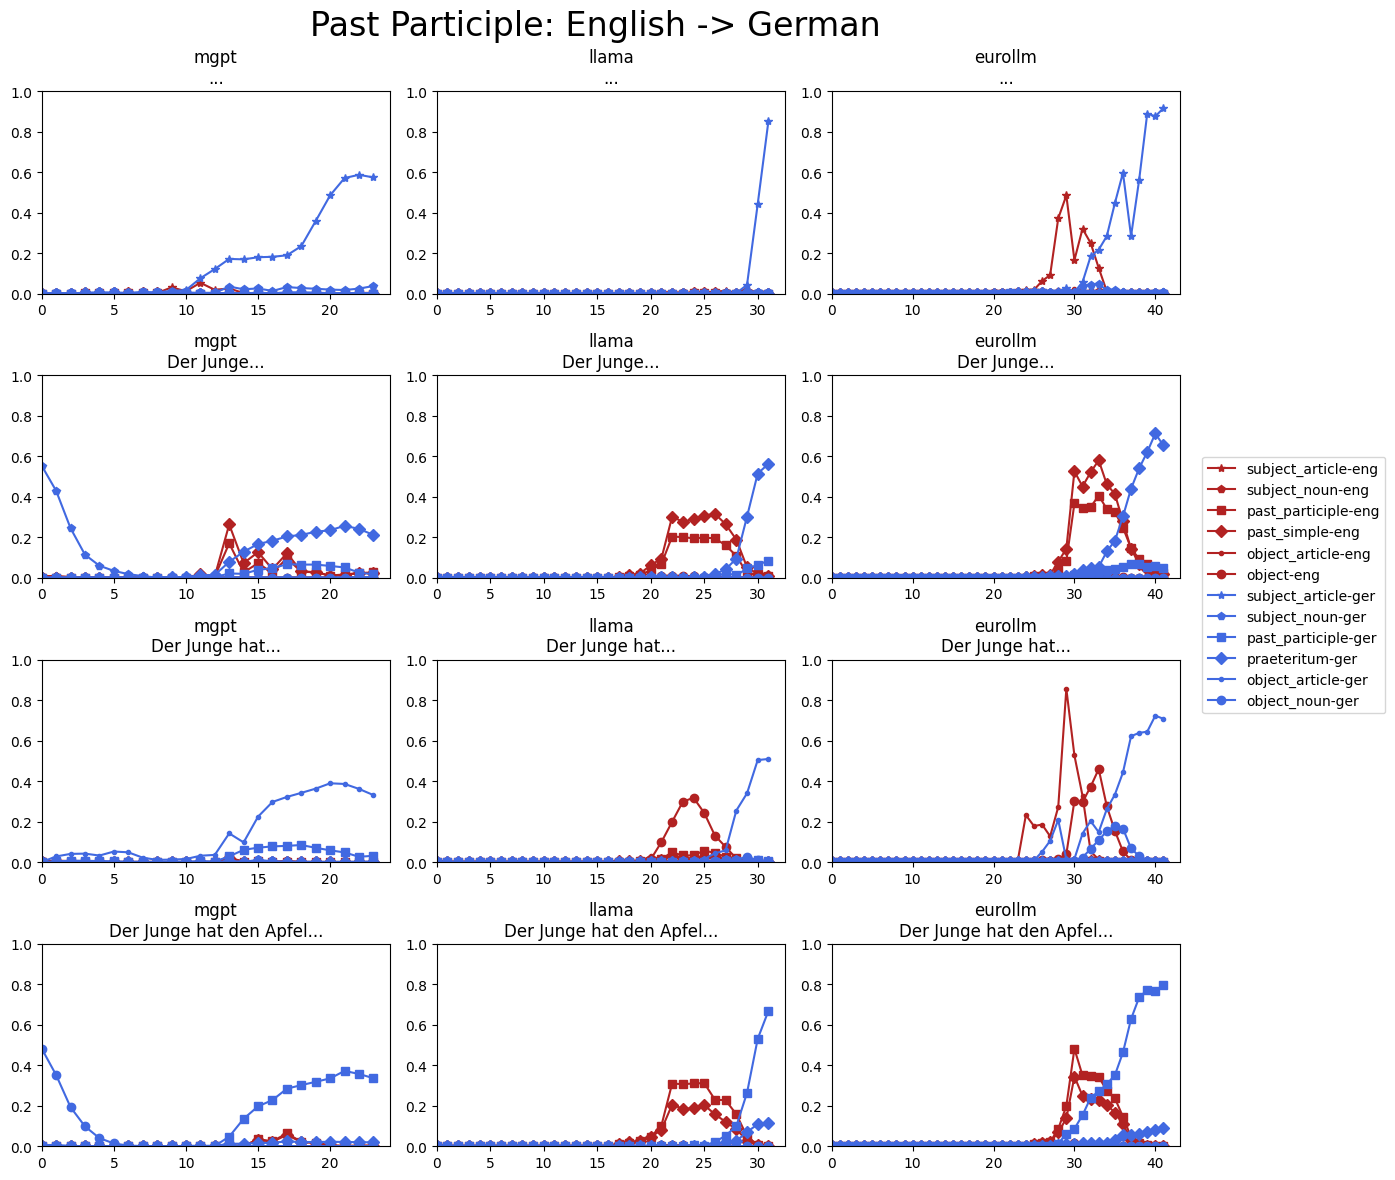

In [8]:
PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_PROMPT_TYPES = [
    "past-participle_instruct_b1eng_b2ger_empty",
    "past-participle_instruct_b1eng_b2ger_cutoff-after-subject-noun",
    "past-participle_instruct_b1eng_b2ger_cutoff-after-auxiliary",
    "past-participle_instruct_b1eng_b2ger_cutoff-after-object-noun",
    ]
PAST_PARTICIPLE_INSTRUCT_B2GER_TITLES = [
    "...",
    "Der Junge...",
    "Der Junge hat...",
    "Der Junge hat den Apfel...",
]
PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_CATEGORIES = [
    'subject_article-eng',
    'subject_noun-eng',
    'past_participle-eng',
    'past_simple-eng',
    'object_article-eng',
    'object-eng',
    'subject_article-ger',
    'subject_noun-ger',
    'past_participle-ger',
    'praeteritum-ger',
    'object_article-ger',
    'object_noun-ger',
]
PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_MARKERS = [
    '*',
    'p',
    's',
    'D',
    '.',
    'o',
    '*',
    'p',
    's',
    'D',
    '.',
    'o',
]
PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_COLORS = [
    'firebrick',
    'firebrick',
    'firebrick',
    'firebrick',
    'firebrick',
    'firebrick',
    'royalblue',
    'royalblue',
    'royalblue',
    'royalblue',
    'royalblue',
    'royalblue'
]

# Usage example:
plot_probs_grid_by_category(
    probs_per_category,
    MODELS_PLOT,
    PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_PROMPT_TYPES,
    PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_CATEGORIES,
    markers=PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_MARKERS,
    colors=PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_COLORS,
    titles=PAST_PARTICIPLE_INSTRUCT_B2GER_TITLES,
    overall_title="Past Participle: English -> German"
)

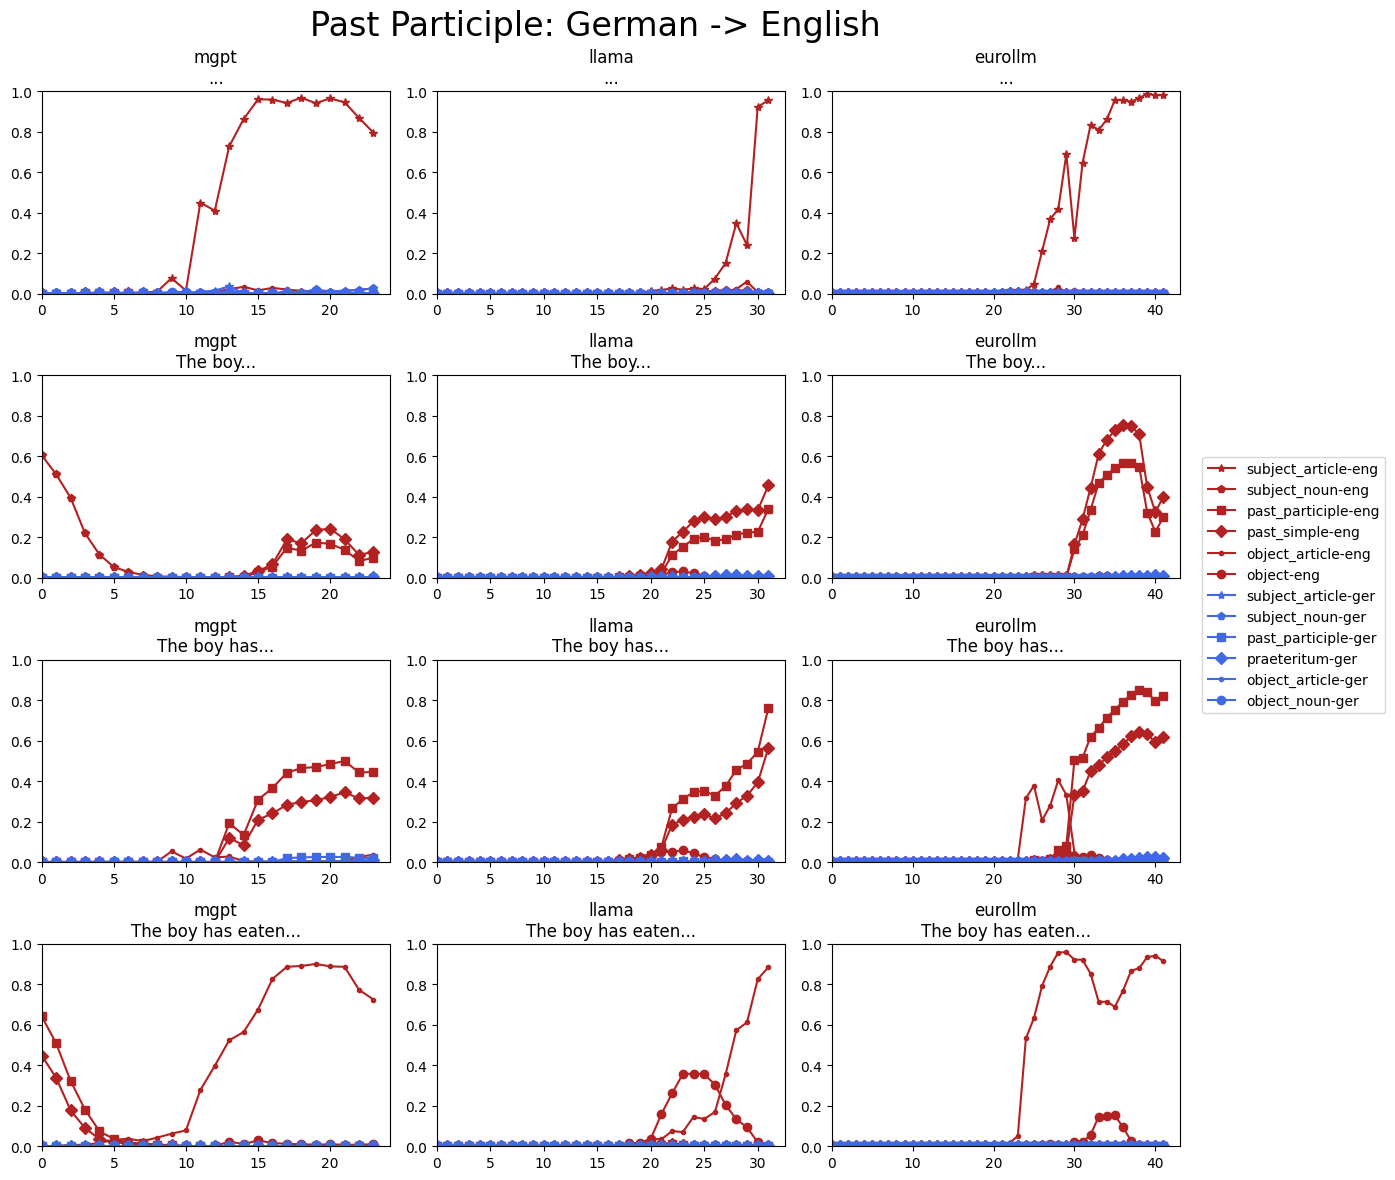

In [9]:
PAST_PARTICIPLE_INSTRUCT_B1GER_B2ENG_PROMPT_TYPES = [
    "past-participle_instruct_b1ger_b2eng_empty",
    "past-participle_instruct_b1ger_b2eng_cutoff-after-subject",
    "past-participle_instruct_b1ger_b2eng_cutoff-after-auxiliary",
    "past-participle_instruct_b1ger_b2eng_cutoff-after-verb",
    ]
PAST_PARTICIPLE_INSTRUCT_B1GER_B2ENG_CATEGORIES = PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_CATEGORIES
PAST_PARTICIPLE_INSTRUCT_B1GER_B2ENG_MARKERS = PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_MARKERS
PAST_PARTICIPLE_INSTRUCT_B1GER_B2ENG_COLORS = PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_COLORS
PAST_PARTICIPLE_INSTRUCT_B2ENG_TITLES = [
    "...",
    "The boy...",
    "The boy has...",
    "The boy has eaten..."
]


# Usage example:
plot_probs_grid_by_category(
    probs_per_category,
    MODELS_PLOT,
    PAST_PARTICIPLE_INSTRUCT_B1GER_B2ENG_PROMPT_TYPES,
    PAST_PARTICIPLE_INSTRUCT_B1GER_B2ENG_CATEGORIES,
    markers=PAST_PARTICIPLE_INSTRUCT_B1GER_B2ENG_MARKERS,
    colors=PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_COLORS,
    titles=PAST_PARTICIPLE_INSTRUCT_B2ENG_TITLES,
    overall_title="Past Participle: German -> English"
)

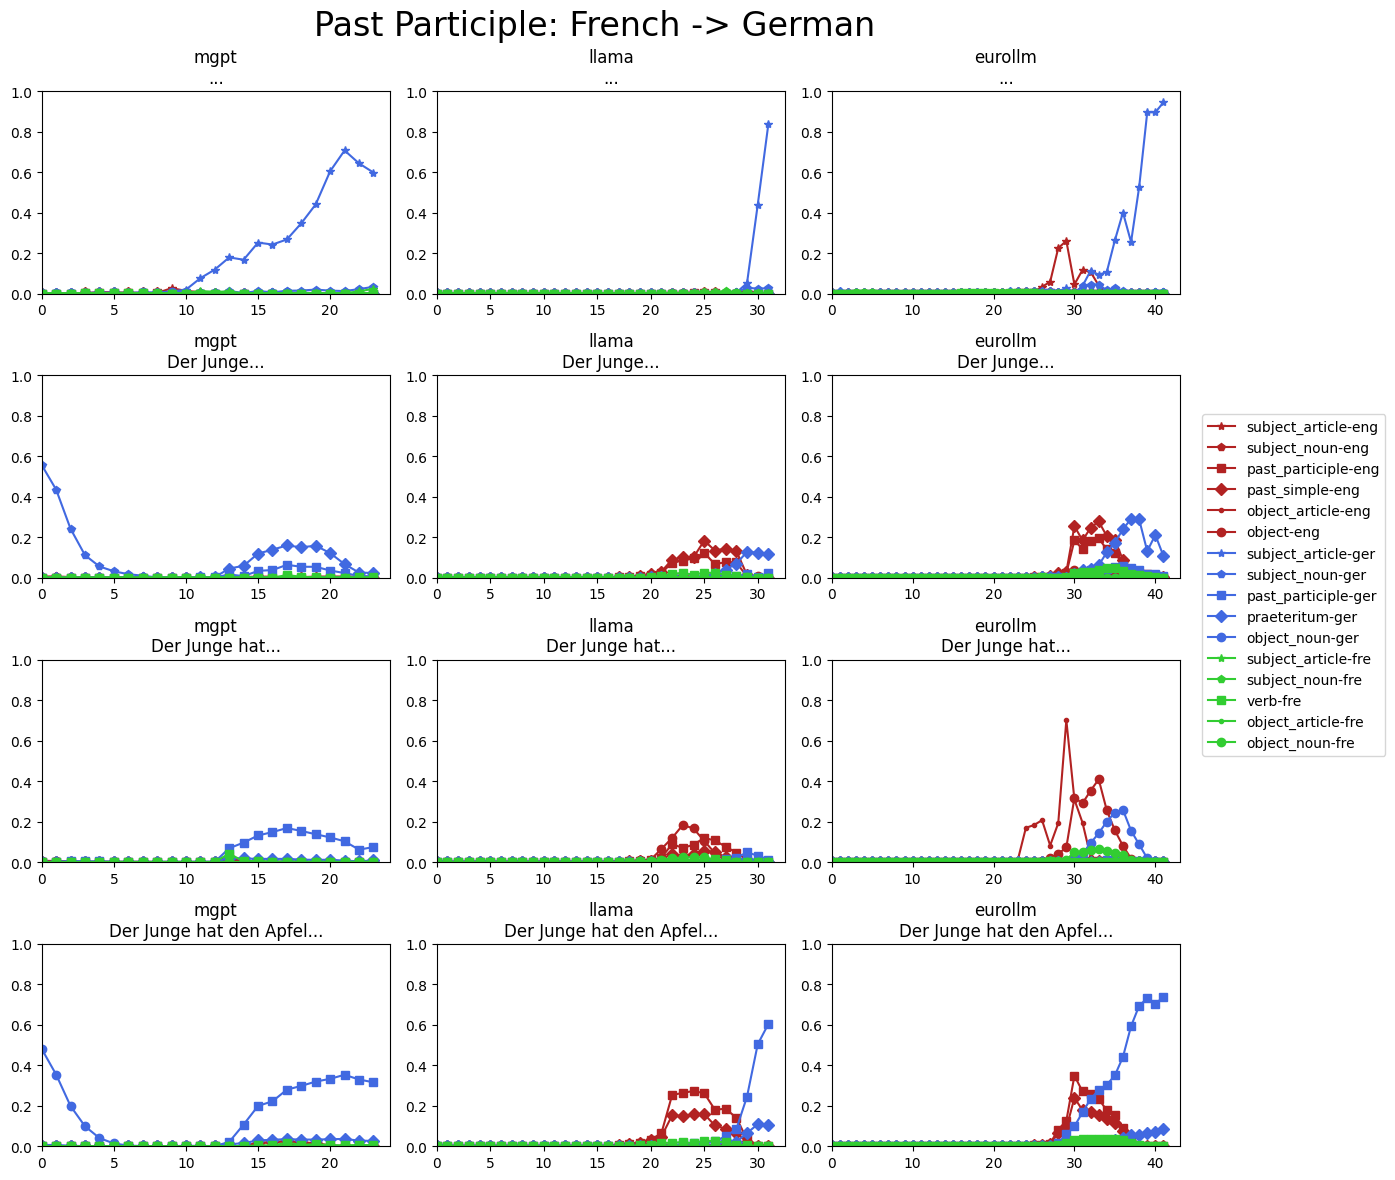

In [10]:
PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_PROMPT_TYPES = [
    "past-participle_instruct_b1fre_b2ger_empty",
    "past-participle_instruct_b1fre_b2ger_cutoff-after-subject-noun",
    "past-participle_instruct_b1fre_b2ger_cutoff-after-auxiliary",
    "past-participle_instruct_b1fre_b2ger_cutoff-after-object-noun",
]
PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_CATEGORIES = PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_CATEGORIES + \
    [
        'subject_article-fre',
        'subject_noun-fre',
        'verb-fre',
        'object_article-fre',
        'object_noun-fre',
    ]
PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_MARKERS = PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_MARKERS + \
    [
        '*',
        'p',
        's',
        '.',
        'o',
    ]
PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_COLORS = PAST_PARTICIPLE_INSTRUCT_B1ENG_B2GER_COLORS + \
    [
        'limegreen',
        'limegreen',
        'limegreen',
        'limegreen',
        'limegreen',
    ]


plot_probs_grid_by_category(
    probs_per_category,
    MODELS_PLOT,
    PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_PROMPT_TYPES,
    PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_CATEGORIES,
    markers=PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_MARKERS,
    colors=PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_COLORS,
    titles=PAST_PARTICIPLE_INSTRUCT_B2GER_TITLES,
    overall_title="Past Participle: French -> German"
)

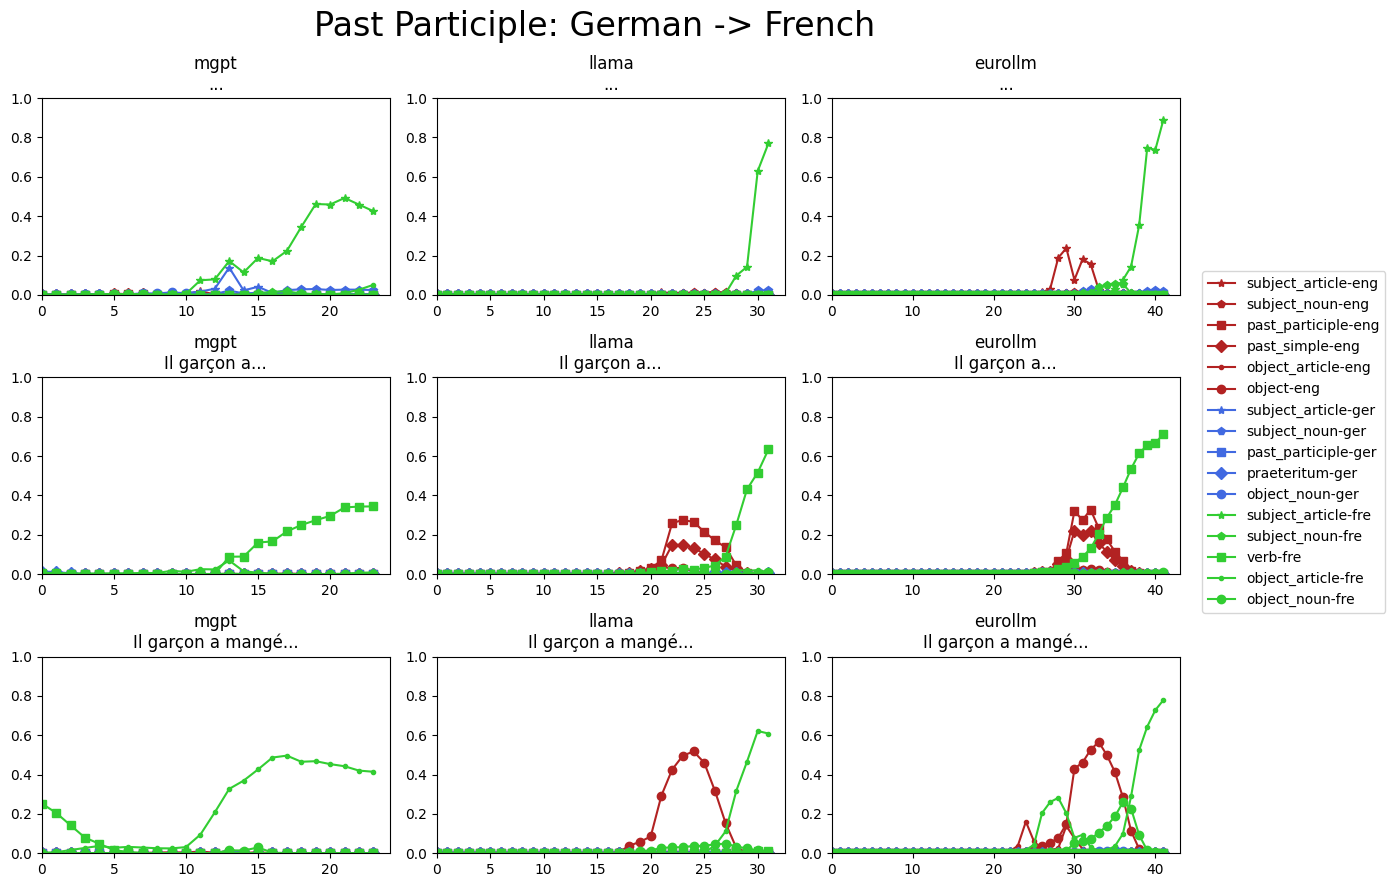

In [11]:
PAST_PARTICIPLE_INSTRUCT_B1GER_B2FRE_PROMPT_TYPES = [
    "past-participle_instruct_b1ger_b2fre_empty",
    "past-participle_instruct_b1ger_b2fre_cutoff-after-auxiliary",
    "past-participle_instruct_b1ger_b2fre_cutoff-after-verb",
    ]

PAST_PARTICIPLE_INSTRUCT_B1GER_B2FRE_CATEGORIES = PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_CATEGORIES
PAST_PARTICIPLE_INSTRUCT_B1GER_B2FRE_MARKERS = PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_MARKERS
PAST_PARTICIPLE_INSTRUCT_B1GER_B2FRE_COLORS = PAST_PARTICIPLE_INSTRUCT_B1FRE_B2GER_COLORS
PAST_PARTICIPLE_INSTRUCT_B2FRE_TITLES = [
    "...",
    "Il garçon a...",
    "Il garçon a mangé..."
]

plot_probs_grid_by_category(
    probs_per_category,
    MODELS_PLOT,
    PAST_PARTICIPLE_INSTRUCT_B1GER_B2FRE_PROMPT_TYPES,
    PAST_PARTICIPLE_INSTRUCT_B1GER_B2FRE_CATEGORIES,
    markers=PAST_PARTICIPLE_INSTRUCT_B1GER_B2FRE_MARKERS,
    colors=PAST_PARTICIPLE_INSTRUCT_B1GER_B2FRE_COLORS,
    titles=PAST_PARTICIPLE_INSTRUCT_B2FRE_TITLES,
    overall_title="Past Participle: German -> French"
)